In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("../data/raw/dataset.csv")

df.head()

In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
df.columns.tolist()

In [33]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
})

missing = missing.sort_values(
    by="missing_percent",
    ascending=False
)

missing

,missing_count,missing_percent
CREDIT_LIMIT,1,0.011173
CUST_ID,0,0.000000
PURCHASES,0,0.000000
BALANCE,0,0.000000
ONEOFF_PURCHASES,0,0.000000
INSTALLMENTS_PURCHASES,0,0.000000
CASH_ADVANCE,0,0.000000
PAYMENTS,0,0.000000


In [ ]:
duplicate_count = df.duplicated().sum()

duplicate_count

In [ ]:
df.dtypes

In [ ]:
numeric_features = [
    "BALANCE",
    "PURCHASES",
    "ONEOFF_PURCHASES",
    "INSTALLMENTS_PURCHASES",
    "CASH_ADVANCE",
    "CREDIT_LIMIT",
    "PAYMENTS"
]

df_numeric = df[numeric_features]
df_numeric

In [ ]:
statistics = df_numeric.describe().T

statistics

In [35]:
skewness = df_numeric.skew()

skewness.sort_values(ascending=False)

ONEOFF_PURCHASES          10.045083
PURCHASES                  8.144269
INSTALLMENTS_PURCHASES     7.299120
PAYMENTS                   5.907620
CASH_ADVANCE               5.166609
BALANCE                    2.393386
CREDIT_LIMIT               1.522464
dtype: float64

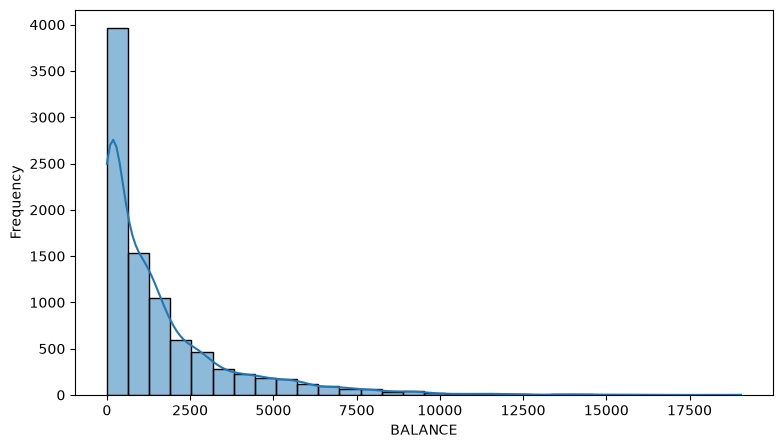

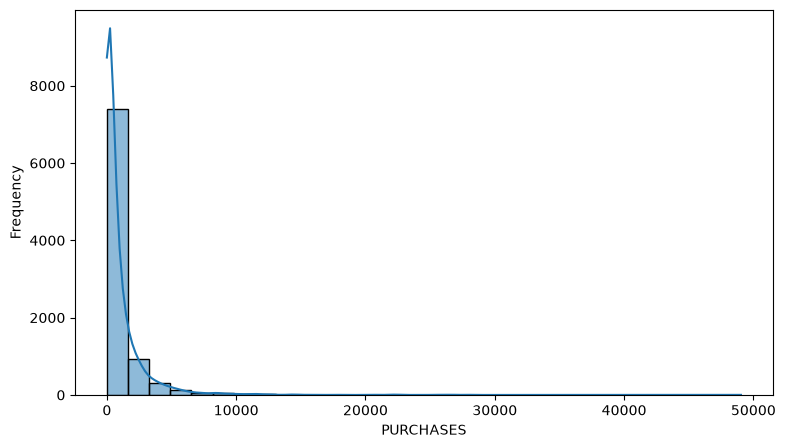

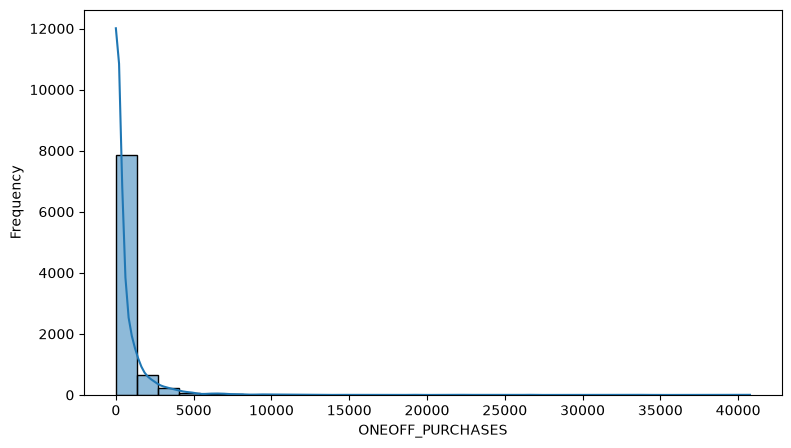

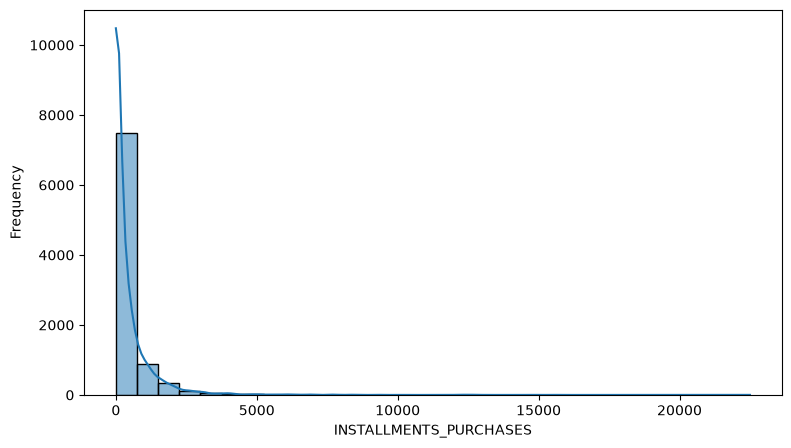

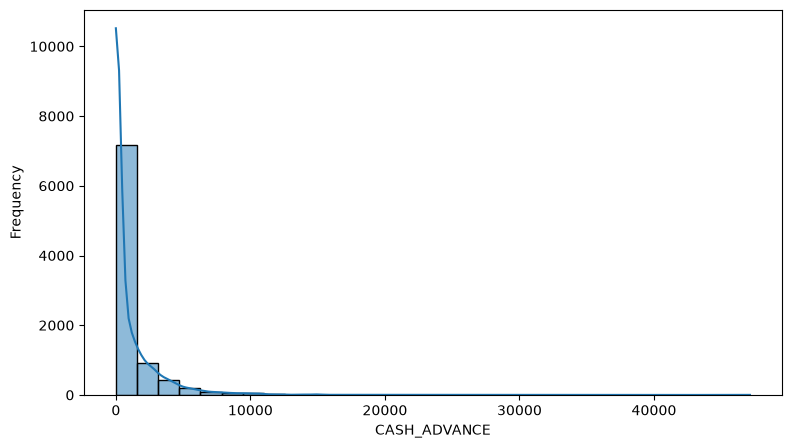

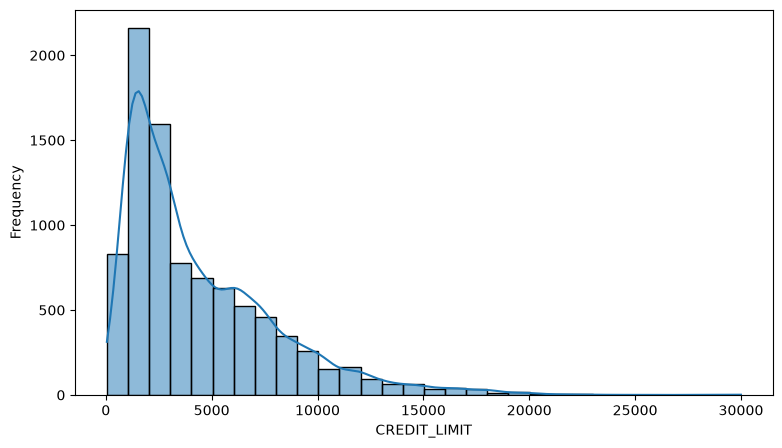

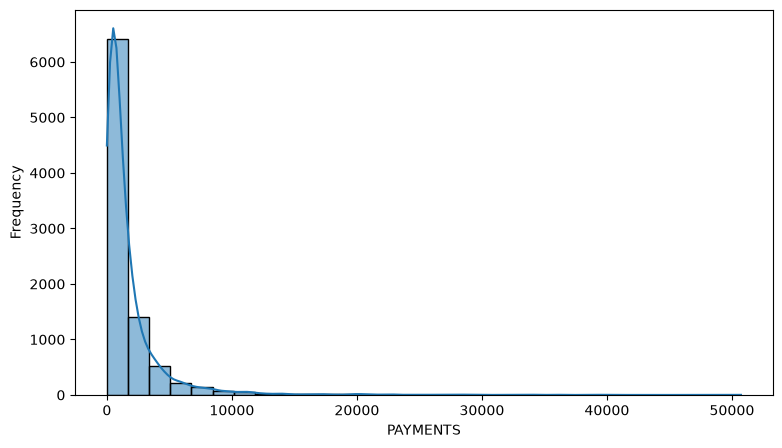

In [34]:
for column in numeric_features:
    skew_value = df[column].skew()

    plt.figure(figsize=(9, 5))

    sns.histplot(
        df[column].dropna(),
        kde=True,
        bins=30
    )


    plt.xlabel(column)
    plt.ylabel("Frequency")

   
    plt.show()

In [ ]:
correlation_matrix = df_numeric.corr(method="pearson")
plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)


plt.show()

In [ ]:
outlier_summary = []

for column in numeric_features:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_summary.append({
        "feature": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": len(outliers)  
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

In [ ]:
for column in numeric_features:

    plt.figure(figsize=(9, 4))

    sns.boxplot(x=df[column])

    plt.xlabel(column)

    plt.tight_layout()
    plt.show()